# Outer Product: Creating Matrices from Vectors

The **outer product** is the opposite of the inner product. Instead of collapsing two vectors into a scalar, it **expands** them into a matrix:

$$\mathbf{x} \mathbf{y}^T = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_m \end{pmatrix} \begin{pmatrix} y_1 & y_2 & \cdots & y_n \end{pmatrix} = \begin{pmatrix} x_1 y_1 & x_1 y_2 & \cdots & x_1 y_n \\ x_2 y_1 & x_2 y_2 & \cdots & x_2 y_n \\ \vdots & \vdots & \ddots & \vdots \\ x_m y_1 & x_m y_2 & \cdots & x_m y_n \end{pmatrix}$$

### Key Properties
- Takes $(m,)$ and $(n,)$ vectors → produces $(m \times n)$ matrix
- Every element is a product: $[\mathbf{x}\mathbf{y}^T]_{ij} = x_i y_j$
- The result is always a **rank-1 matrix** (all rows are multiples of each other)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

---
## 1. Computing the Outer Product

The outer product creates **all pairwise products** between elements of two vectors.

In [2]:
# Basic outer product
x = np.array([1, 2, 3])
y = np.array([4, 5])

# Compute outer product
outer = np.outer(x, y)

print(f"x = {x}  (length {len(x)})")
print(f"y = {y}  (length {len(y)})")
print(f"\nx ⊗ y = x @ y.T:")
print(outer)
print(f"\nShape: {outer.shape}")
print(f"\nHow it's computed:")
print(f"[1×4  1×5]   [{x[0]*y[0]}  {x[0]*y[1]}]")
print(f"[2×4  2×5] = [{x[1]*y[0]} {x[1]*y[1]}]")
print(f"[3×4  3×5]   [{x[2]*y[0]} {x[2]*y[1]}]")

x = [1 2 3]  (length 3)
y = [4 5]  (length 2)

x ⊗ y = x @ y.T:
[[ 4  5]
 [ 8 10]
 [12 15]]

Shape: (3, 2)

How it's computed:
[1×4  1×5]   [4  5]
[2×4  2×5] = [8 10]
[3×4  3×5]   [12 15]


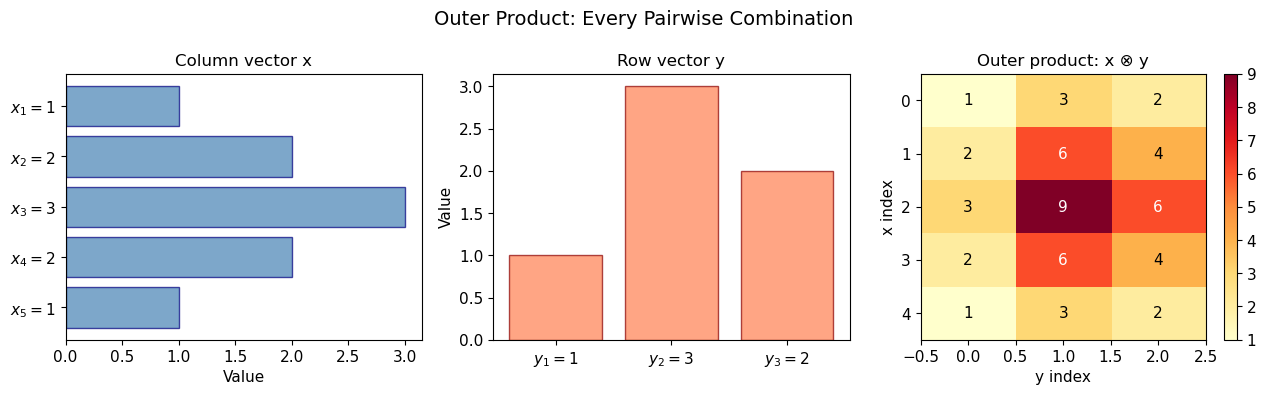

In [3]:
# Visualize outer product as a heatmap
x = np.array([1, 2, 3, 2, 1])
y = np.array([1, 3, 2])
outer = np.outer(x, y)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Vector x (column) - shown as horizontal bar for visual clarity
ax0 = axes[0]
ax0.barh(range(len(x)), x, color='steelblue', alpha=0.7, edgecolor='navy')
ax0.set_yticks(range(len(x)))
ax0.set_yticklabels([f'$x_{i+1}={v}$' for i, v in enumerate(x)])
ax0.invert_yaxis()  # Match matrix orientation
ax0.set_xlabel('Value')
ax0.set_title('Column vector x', fontsize=12)

# Vector y (row)
ax1 = axes[1]
ax1.bar(range(len(y)), y, color='coral', alpha=0.7, edgecolor='darkred')
ax1.set_xticks(range(len(y)))
ax1.set_xticklabels([f'$y_{j+1}={v}$' for j, v in enumerate(y)])
ax1.set_ylabel('Value')
ax1.set_title('Row vector y', fontsize=12)

# Outer product matrix
ax2 = axes[2]
im = ax2.imshow(outer, cmap='YlOrRd', aspect='auto')
ax2.set_title('Outer product: x ⊗ y', fontsize=12)
ax2.set_xlabel('y index')
ax2.set_ylabel('x index')
for i in range(len(x)):
    for j in range(len(y)):
        ax2.text(j, i, f'{outer[i,j]}', ha='center', va='center', fontsize=11,
                color='white' if outer[i,j] > 5 else 'black')
plt.colorbar(im, ax=ax2)

plt.suptitle('Outer Product: Every Pairwise Combination', fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. Rank-1 Property: All Rows Are Proportional

An outer product creates a **rank-1 matrix**. This means:
- All rows are scalar multiples of each other
- All columns are scalar multiples of each other
- The matrix can be "compressed" back to two vectors

In [4]:
# Demonstrate rank-1 property
x = np.array([1, 2, 4])
y = np.array([3, 1, 2])
outer = np.outer(x, y)

print("Outer product matrix:")
print(outer)
print(f"\nMatrix rank: {np.linalg.matrix_rank(outer)}")

print("\nAll rows are multiples of the first row:")
for i in range(len(x)):
    ratio = x[i] / x[0]
    print(f"  Row {i+1} = {ratio:.0f} × Row 1: {outer[i]} = {ratio:.0f} × {outer[0]}")

print("\nAll columns are multiples of the first column:")
for j in range(len(y)):
    ratio = y[j] / y[0]
    print(f"  Col {j+1} = {ratio:.1f} × Col 1: {outer[:,j]} = {ratio:.1f} × {outer[:,0]}")

Outer product matrix:
[[ 3  1  2]
 [ 6  2  4]
 [12  4  8]]

Matrix rank: 1

All rows are multiples of the first row:
  Row 1 = 1 × Row 1: [3 1 2] = 1 × [3 1 2]
  Row 2 = 2 × Row 1: [6 2 4] = 2 × [3 1 2]
  Row 3 = 4 × Row 1: [12  4  8] = 4 × [3 1 2]

All columns are multiples of the first column:
  Col 1 = 1.0 × Col 1: [ 3  6 12] = 1.0 × [ 3  6 12]
  Col 2 = 0.3 × Col 1: [1 2 4] = 0.3 × [ 3  6 12]
  Col 3 = 0.7 × Col 1: [2 4 8] = 0.7 × [ 3  6 12]


---
## Real-World Scenario: Building Covariance from Data

**Scenario**: You're analyzing stock returns for a portfolio. The **covariance matrix** tells you how stocks move together. It's built as a **sum of outer products**!

$$\mathbf{\Sigma} = \frac{1}{n-1} \sum_{i=1}^n (\mathbf{x}_i - \bar{\mathbf{x}})(\mathbf{x}_i - \bar{\mathbf{x}})^T$$

Each data point contributes a rank-1 "snapshot" of how variables co-vary that day.

In [5]:
# Simulate stock returns
np.random.seed(42)
n_days = 20
stocks = ['AAPL', 'MSFT', 'GOOGL']

# Create correlated returns
true_cov = np.array([
    [0.04, 0.02, 0.015],
    [0.02, 0.03, 0.018],
    [0.015, 0.018, 0.035]
]) / 100  # Daily returns variance

L = np.linalg.cholesky(true_cov)
returns = np.random.randn(n_days, 3) @ L.T

print("Daily Returns (first 8 days)")
print("=" * 50)
print(f"{'Day':>4}  {stocks[0]:>10}  {stocks[1]:>10}  {stocks[2]:>10}")
print("-" * 50)
for i in range(8):
    print(f"{i+1:>4}  {returns[i,0]*100:>9.2f}%  {returns[i,1]*100:>9.2f}%  {returns[i,2]*100:>9.2f}%")
print("...")

Daily Returns (first 8 days)
 Day        AAPL        MSFT       GOOGL
--------------------------------------------------
   1       0.99%       0.30%       1.27%
   2       3.05%       1.19%       0.61%
   3       3.16%       2.66%       1.03%
   4       1.09%      -0.11%      -0.66%
   5       0.48%      -2.46%      -3.90%
   6      -1.12%      -1.99%      -0.69%
   7      -1.82%      -2.91%       0.53%
   8      -0.45%      -0.13%      -2.32%
...


In [6]:
# Build covariance matrix step by step using outer products
returns_centered = returns - returns.mean(axis=0)

print("Step 1: Center the data (subtract mean)")
print(f"Mean returns: {returns.mean(axis=0) * 100}")
print(f"After centering, mean ≈ 0: {returns_centered.mean(axis=0).round(10)}")

Step 1: Center the data (subtract mean)
Mean returns: [ 0.11098445 -0.32030287 -0.54762094]
After centering, mean ≈ 0: [ 0.  0. -0.]


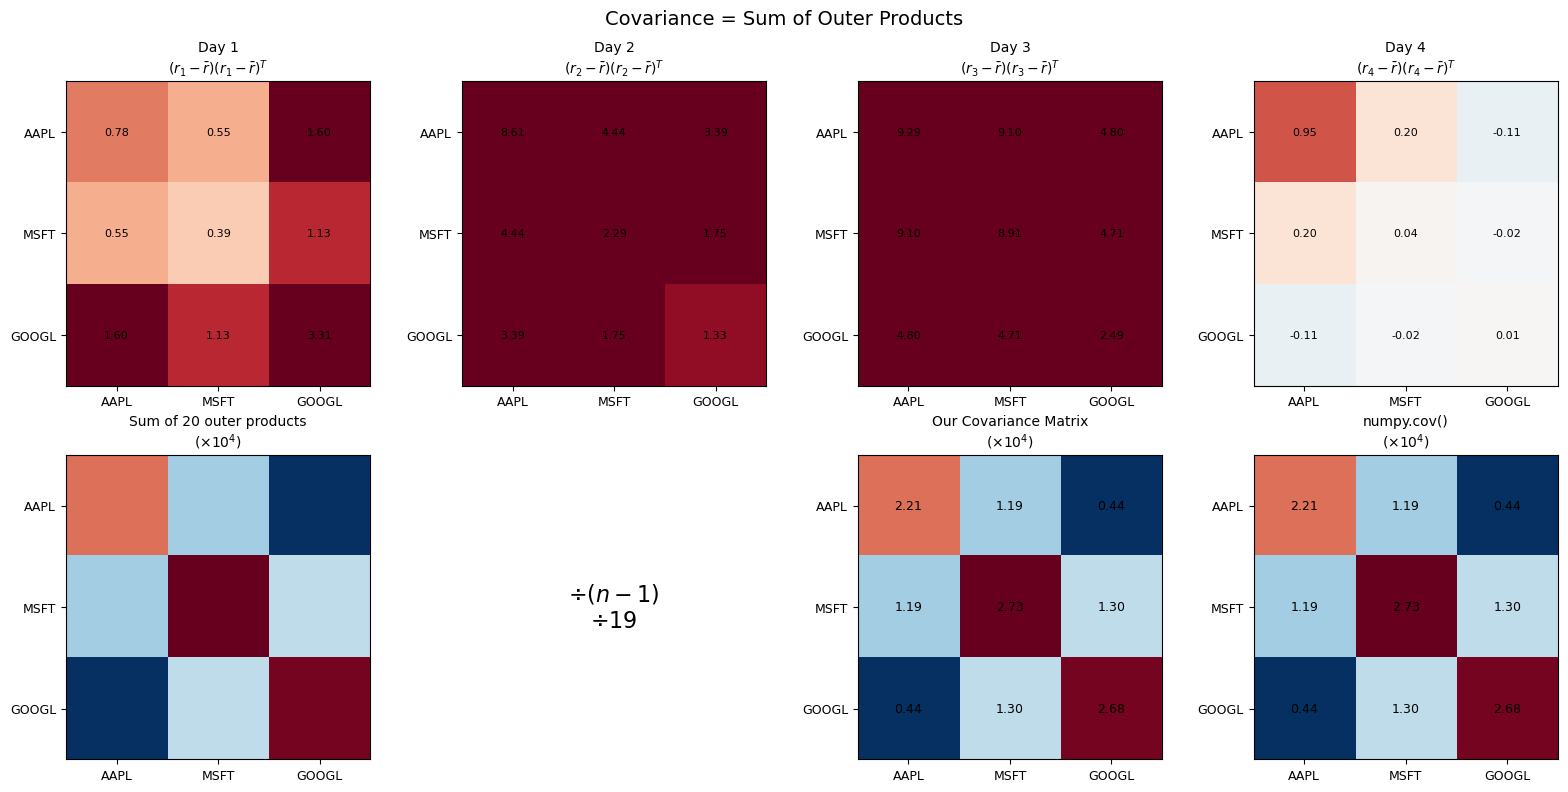

Our result matches numpy.cov(): True


In [8]:
# Visualize individual outer products
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

cov_accumulator = np.zeros((3, 3))

# Show first 4 days' contributions
for day in range(4):
    ax = axes[0, day]
    r = returns_centered[day]  # Centered return for this day
    outer_product = np.outer(r, r)  # This day's contribution
    cov_accumulator += outer_product
    
    im = ax.imshow(outer_product * 10000, cmap='RdBu_r', vmin=-1.5, vmax=1.5)
    ax.set_title(f'Day {day+1}\n$(r_{day+1} - \\bar{{r}})(r_{day+1} - \\bar{{r}})^T$', fontsize=10)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(stocks, fontsize=9)
    ax.set_yticklabels(stocks, fontsize=9)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{outer_product[i,j]*10000:.2f}', ha='center', va='center', fontsize=8)

# Sum all days
cov_sum = np.zeros((3, 3))
for day in range(n_days):
    r = returns_centered[day]
    cov_sum += np.outer(r, r)

# Show sum and final covariance
ax_sum = axes[1, 0]
im1 = ax_sum.imshow(cov_sum * 10000, cmap='RdBu_r')
ax_sum.set_title(f'Sum of {n_days} outer products\n(×$10^4$)', fontsize=10)
ax_sum.set_xticks(range(3)); ax_sum.set_yticks(range(3))
ax_sum.set_xticklabels(stocks, fontsize=9); ax_sum.set_yticklabels(stocks, fontsize=9)

ax_div = axes[1, 1]
ax_div.text(0.5, 0.5, f'$\\div (n-1)$\n$\\div {n_days-1}$', fontsize=16, 
            ha='center', va='center', transform=ax_div.transAxes)
ax_div.axis('off')

ax_cov = axes[1, 2]
cov_manual = cov_sum / (n_days - 1)
im2 = ax_cov.imshow(cov_manual * 10000, cmap='RdBu_r')
ax_cov.set_title('Our Covariance Matrix\n(×$10^4$)', fontsize=10)
ax_cov.set_xticks(range(3)); ax_cov.set_yticks(range(3))
ax_cov.set_xticklabels(stocks, fontsize=9); ax_cov.set_yticklabels(stocks, fontsize=9)
for i in range(3):
    for j in range(3):
        ax_cov.text(j, i, f'{cov_manual[i,j]*10000:.2f}', ha='center', va='center', fontsize=9)

ax_np = axes[1, 3]
cov_numpy = np.cov(returns.T)
im3 = ax_np.imshow(cov_numpy * 10000, cmap='RdBu_r')
ax_np.set_title('numpy.cov()\n(×$10^4$)', fontsize=10)
ax_np.set_xticks(range(3)); ax_np.set_yticks(range(3))
ax_np.set_xticklabels(stocks, fontsize=9); ax_np.set_yticklabels(stocks, fontsize=9)
for i in range(3):
    for j in range(3):
        ax_np.text(j, i, f'{cov_numpy[i,j]*10000:.2f}', ha='center', va='center', fontsize=9)

plt.suptitle('Covariance = Sum of Outer Products', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Our result matches numpy.cov(): {np.allclose(cov_manual, cov_numpy)}")

In [9]:
# Interpret the covariance matrix
print("Interpreting the Covariance Matrix")
print("=" * 50)
print(f"\nVariances (diagonal):")
for i, stock in enumerate(stocks):
    var = cov_numpy[i, i]
    vol = np.sqrt(var) * np.sqrt(252) * 100  # Annualized volatility
    print(f"  {stock}: variance = {var*10000:.4f}×10⁻⁴, annualized vol = {vol:.1f}%")

print(f"\nCorrelations (off-diagonal, normalized):")
corr = np.corrcoef(returns.T)
for i in range(3):
    for j in range(i+1, 3):
        print(f"  ρ({stocks[i]}, {stocks[j]}) = {corr[i,j]:.3f}")

Interpreting the Covariance Matrix

Variances (diagonal):
  AAPL: variance = 2.2106×10⁻⁴, annualized vol = 23.6%
  MSFT: variance = 2.7252×10⁻⁴, annualized vol = 26.2%
  GOOGL: variance = 2.6769×10⁻⁴, annualized vol = 26.0%

Correlations (off-diagonal, normalized):
  ρ(AAPL, MSFT) = 0.484
  ρ(AAPL, GOOGL) = 0.181
  ρ(MSFT, GOOGL) = 0.480


---
## 3. Matrix Formulation

There's an elegant way to compute the covariance using matrix notation:

$$\mathbf{\Sigma} = \frac{1}{n-1} \mathbf{X}_c^T \mathbf{X}_c$$

Where $\mathbf{X}_c$ is the centered data matrix (each row is one observation).

This is equivalent to summing outer products, but computed as a single matrix multiplication!

In [10]:
# Compare the two formulations
X_centered = returns_centered  # (n_days × 3)

# Method 1: Sum of outer products
cov_outer = np.zeros((3, 3))
for i in range(n_days):
    cov_outer += np.outer(X_centered[i], X_centered[i])
cov_outer /= (n_days - 1)

# Method 2: Matrix multiplication
cov_matrix = (X_centered.T @ X_centered) / (n_days - 1)

print("Sum of outer products:")
print(cov_outer * 10000)
print("\nMatrix multiplication X.T @ X / (n-1):")
print(cov_matrix * 10000)
print(f"\nSame result: {np.allclose(cov_outer, cov_matrix)}")
print(f"\nMatrix method is much faster for large n!")

Sum of outer products:
[[2.21061156 1.18693107 0.43948107]
 [1.18693107 2.72519355 1.29637267]
 [0.43948107 1.29637267 2.67693415]]

Matrix multiplication X.T @ X / (n-1):
[[2.21061156 1.18693107 0.43948107]
 [1.18693107 2.72519355 1.29637267]
 [0.43948107 1.29637267 2.67693415]]

Same result: True

Matrix method is much faster for large n!


---
## 4. Low-Rank Approximation

Since an outer product gives a rank-1 matrix, we can **approximate** any matrix as a sum of outer products:

$$\mathbf{A} \approx \sum_{k=1}^r \sigma_k \mathbf{u}_k \mathbf{v}_k^T$$

This is the **Singular Value Decomposition (SVD)** — incredibly useful for compression and dimensionality reduction.

In [11]:
# Create a simple image-like matrix
np.random.seed(123)
n = 20

# Create a matrix with some structure (not random)
x = np.linspace(0, 2*np.pi, n)
y = np.linspace(0, 2*np.pi, n)
X, Y = np.meshgrid(x, y)
A = np.sin(X) * np.cos(Y) + 0.5 * np.sin(2*X) + 0.3 * np.random.randn(n, n)

# SVD decomposition
U, s, Vt = np.linalg.svd(A)

print(f"Original matrix shape: {A.shape}")
print(f"Singular values: {s[:5].round(2)} ...")
print(f"\nMatrix rank: {np.linalg.matrix_rank(A)}")
print(f"But first few singular values dominate!")

Original matrix shape: (20, 20)
Singular values: [10.05  6.83  2.42  2.02  1.99] ...

Matrix rank: 20
But first few singular values dominate!


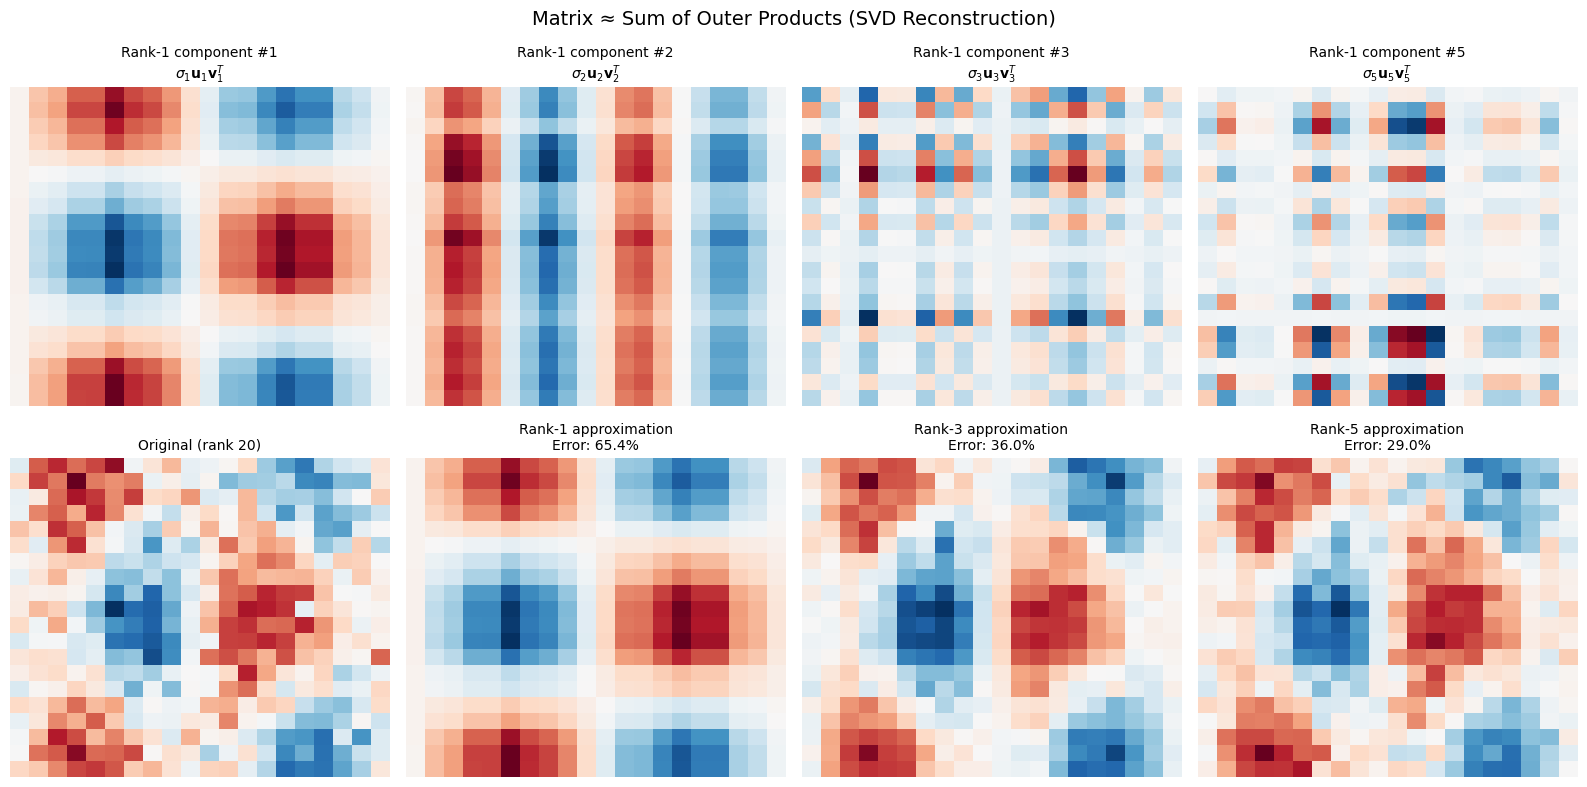

In [12]:
# Reconstruct using different numbers of outer products
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

ranks = [1, 2, 3, 5]

# Top row: show individual rank-1 components
for idx, r in enumerate(ranks[:4]):
    ax = axes[0, idx]
    # The r-th outer product
    component = s[r-1] * np.outer(U[:, r-1], Vt[r-1, :])
    im = ax.imshow(component, cmap='RdBu_r', aspect='auto')
    ax.set_title(f'Rank-1 component #{r}\n$\\sigma_{r} \\mathbf{{u}}_{r} \\mathbf{{v}}_{r}^T$', fontsize=10)
    ax.axis('off')

# Bottom row: cumulative reconstruction
ax_orig = axes[1, 0]
ax_orig.imshow(A, cmap='RdBu_r', aspect='auto')
ax_orig.set_title(f'Original (rank {np.linalg.matrix_rank(A)})', fontsize=10)
ax_orig.axis('off')

for idx, r in enumerate([1, 3, 5]):
    ax = axes[1, idx+1]
    # Reconstruction using first r outer products
    A_approx = sum(s[k] * np.outer(U[:, k], Vt[k, :]) for k in range(r))
    error = np.linalg.norm(A - A_approx) / np.linalg.norm(A) * 100
    
    im = ax.imshow(A_approx, cmap='RdBu_r', aspect='auto')
    ax.set_title(f'Rank-{r} approximation\nError: {error:.1f}%', fontsize=10)
    ax.axis('off')

plt.suptitle('Matrix ≈ Sum of Outer Products (SVD Reconstruction)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Outer Products in Machine Learning

The outer product appears in many ML contexts:

| Application | Formula | Meaning |
|-------------|---------|----------|
| Covariance matrix | $\sum_i \mathbf{x}_i \mathbf{x}_i^T$ | How features co-vary |
| Attention (Transformers) | $\text{softmax}(\mathbf{q}^T\mathbf{k})\mathbf{v}^T$ | Weighted outer products |
| Gradient updates | $\nabla_W = \mathbf{a} \mathbf{\delta}^T$ | Weight change pattern |
| PCA | $\mathbf{X}^T\mathbf{X}$ eigenvectors | Principal directions |

In [13]:
# Example: Gradient update as outer product
# In a neural network layer: output = W @ input
# Gradient w.r.t. W is: ∂L/∂W = (upstream_gradient) ⊗ (input)

input_activation = np.array([0.5, 0.8, 0.3])  # Previous layer output
upstream_gradient = np.array([0.1, -0.2])     # Gradient from next layer

# Weight gradient is an outer product!
weight_gradient = np.outer(upstream_gradient, input_activation)

print("Neural Network Gradient as Outer Product")
print("=" * 50)
print(f"Input activation (a): {input_activation}")
print(f"Upstream gradient (δ): {upstream_gradient}")
print(f"\n∂L/∂W = δ ⊗ a:")
print(weight_gradient)
print(f"\nThis tells us: if a_j is large and δ_i is large,")
print(f"then W[i,j] contributed a lot to the error.")

Neural Network Gradient as Outer Product
Input activation (a): [0.5 0.8 0.3]
Upstream gradient (δ): [ 0.1 -0.2]

∂L/∂W = δ ⊗ a:
[[ 0.05  0.08  0.03]
 [-0.1  -0.16 -0.06]]

This tells us: if a_j is large and δ_i is large,
then W[i,j] contributed a lot to the error.


---
## Key Takeaways

1. **Outer product** $\mathbf{x} \mathbf{y}^T$ creates a matrix from two vectors
   - Element $(i,j)$ is $x_i \times y_j$
   - Result is always rank-1

2. **Covariance = sum of outer products**
   - Each data point contributes $(\mathbf{x}_i - \bar{\mathbf{x}})(\mathbf{x}_i - \bar{\mathbf{x}})^T$
   - Equivalently: $\mathbf{X}_c^T \mathbf{X}_c / (n-1)$

3. **Any matrix is a sum of outer products** (SVD)
   - Enables low-rank approximation
   - Foundation for PCA, compression, denoising

4. **Compare inner vs outer**:
   - Inner: $\mathbf{x}^T \mathbf{y}$ → scalar (similarity)
   - Outer: $\mathbf{x} \mathbf{y}^T$ → matrix (structure)

**Next**: We'll explore **matrix-vector multiplication** — how matrices transform vectors geometrically.